# ⚙️ Preprocesamiento de Datos Magnetotelúricos
---
**Curso:** Magnetotelúrica desde Cero: Fundamentos, Procesamiento e Interpretación de Datos  
**Módulo 3 — Análisis e Interpretación de Datos MT**

En este notebook se realiza el **preprocesamiento** de los datos MT crudos:
1. Carga del H5 crudo generado en el Notebook 1.
2. **Inspección y eliminación** de frecuencias con alta dispersión (outliers).
3. **Interpolación** de las curvas a una grilla de periodos común.
4. Exportación de los datos procesados como nuevos archivos EDI y H5.

> **Prerequisito:** Haber ejecutado el Notebook 1 y tener el archivo
> `h5/collection_crudo.h5` disponible en la carpeta h5. Haber creado una copia del archivo h5  `collection_crudo.h5` en la carpeta "h5_procesado" y cambiarle el nombre a `collection_procesado.h5`, para no modificar el archivo original.

Una vez revisado cada uno de los sondeos magnetotelúricos se realiza el procesamiento de los datos, en donde se eliminan las frecuencias que presenten alta dispersión. Se debe crear una copia del archivo h5 crudo "collection_crudo.h5" en la carpeta "h5_procesado" y cambiarle el nombre a"collection_procesado.h5", para no modificar el archivo original

<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 1 · Importar librerías</span></div>


In [57]:
# Importar librerías
from pathlib import Path
from mtpy import MT, MTData, MTCollection
import h5py
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 2 · Cargar datos y visualizar sondeos originales</span></div>

In [58]:
# Convertir a MTData
with MTCollection() as mc:
    mc.open_collection(Path("h5_procesado/"+"collection_crudo.h5")) # Ruta del h5 crudo
    mtd = mc.to_mt_data()
    #mc.close_collection()


26:03:17T09:27:03 | INFO | line:777 |mth5.mth5 | close_mth5 | Flushing and closing h5_procesado\collection_crudo.h5


In [59]:
mtd.station_locations

,survey,station,latitude,longitude,elevation,datum_epsg,east,north,utm_epsg,model_east,model_north,model_elevation,profile_offset
0,edi,MC0001,4.453861,-75.337556,2091.0,4326,0.0,0.0,None,0.0,0.0,2091.0,0.0
1,edi,MC0002,4.469861,-75.389528,2125.0,4326,0.0,0.0,None,0.0,0.0,2125.0,0.0
2,edi,MC0006,4.444083,-75.357556,1820.0,4326,0.0,0.0,None,0.0,0.0,1820.0,0.0
3,edi,MC0007,4.459944,-75.348806,2070.0,4326,0.0,0.0,None,0.0,0.0,2070.0,0.0
4,edi,MC0008,4.449639,-75.347694,1787.0,4326,0.0,0.0,None,0.0,0.0,1787.0,0.0
5,edi,MC0009,4.451389,-75.329444,2381.0,4326,0.0,0.0,None,0.0,0.0,2381.0,0.0
6,edi,MC0010,4.469139,-75.350861,2098.0,4326,0.0,0.0,None,0.0,0.0,2098.0,0.0
7,edi,MC0011,4.454306,-75.377139,1812.0,4326,0.0,0.0,None,0.0,0.0,1812.0,0.0
8,edi,MC0012,4.459917,-75.329222,2223.0,4326,0.0,0.0,None,0.0,0.0,2223.0,0.0
9,edi,MC0013,4.459583,-75.359889,2185.0,4326,0.0,0.0,None,0.0,0.0,2185.0,0.0


<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 4 · Interpolar los datos</span></div>

<div style="background:#f0f9ef;border-left:5px solid #27AE60;padding:10px 14px;border-radius:4px;margin:6px 0">La <b>interpolación</b> en MT se realiza en el dominio del logaritmo del periodo (log-periodo), ya que las curvas son suaves en esa escala. <code>np.logspace(a, b, n)</code> genera <i>n</i> puntos equiespaciados en escala logarítmica entre 10<sup>a</sup> y 10<sup>b</sup> segundos. El rango debe estar <b>dentro del rango medido</b> de todos los sondeos para evitar extrapolación.</div>

In [60]:
new_periods = np.logspace(-2.3, 0, 50)

In [61]:
interpolated_mtd = mtd.interpolate(new_periods, inplace=False)

In [62]:
interpolated_mtd

MTData([('edi.MC0001',
         TF( survey='edi', station='MC0001', latitude=4.45, longitude=-75.34, elevation=2091.00 )),
        ('edi.MC0002',
         TF( survey='edi', station='MC0002', latitude=4.47, longitude=-75.39, elevation=2125.00 )),
        ('edi.MC0006',
         TF( survey='edi', station='MC0006', latitude=4.44, longitude=-75.36, elevation=1820.00 )),
        ('edi.MC0007',
         TF( survey='edi', station='MC0007', latitude=4.46, longitude=-75.35, elevation=2070.00 )),
        ('edi.MC0008',
         TF( survey='edi', station='MC0008', latitude=4.45, longitude=-75.35, elevation=1787.00 )),
        ('edi.MC0009',
         TF( survey='edi', station='MC0009', latitude=4.45, longitude=-75.33, elevation=2381.00 )),
        ('edi.MC0010',
         TF( survey='edi', station='MC0010', latitude=4.47, longitude=-75.35, elevation=2098.00 )),
        ('edi.MC0011',
         TF( survey='edi', station='MC0011', latitude=4.45, longitude=-75.38, elevation=1812.00 )),
        ('edi.MC

**Datos originales**

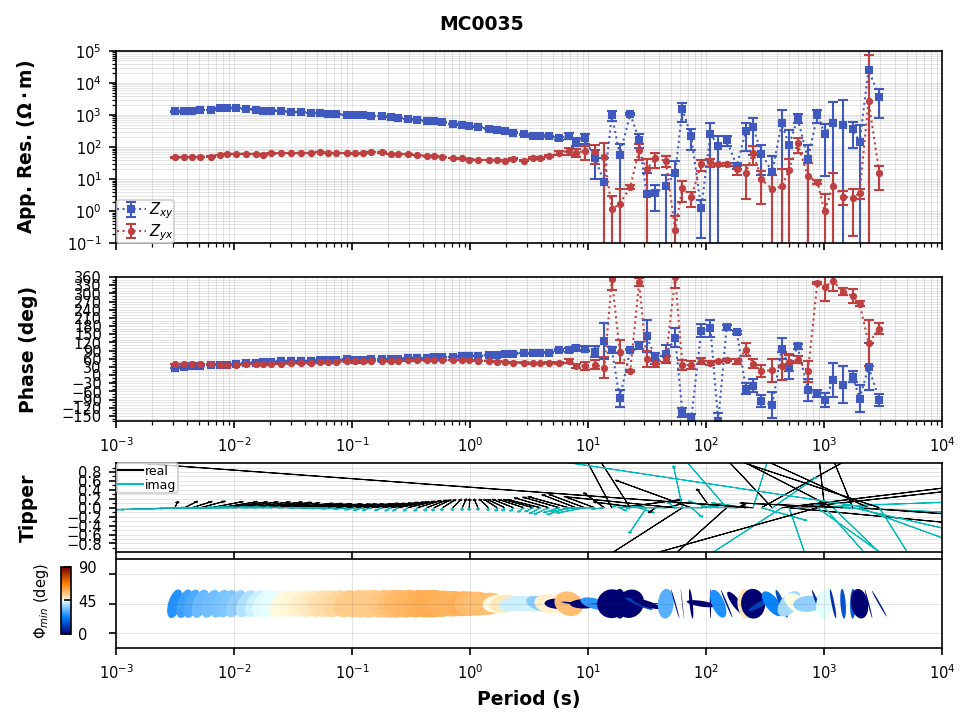

In [63]:
original = mtd.plot_mt_response("edi.MC0035")

**Datos interpolados**

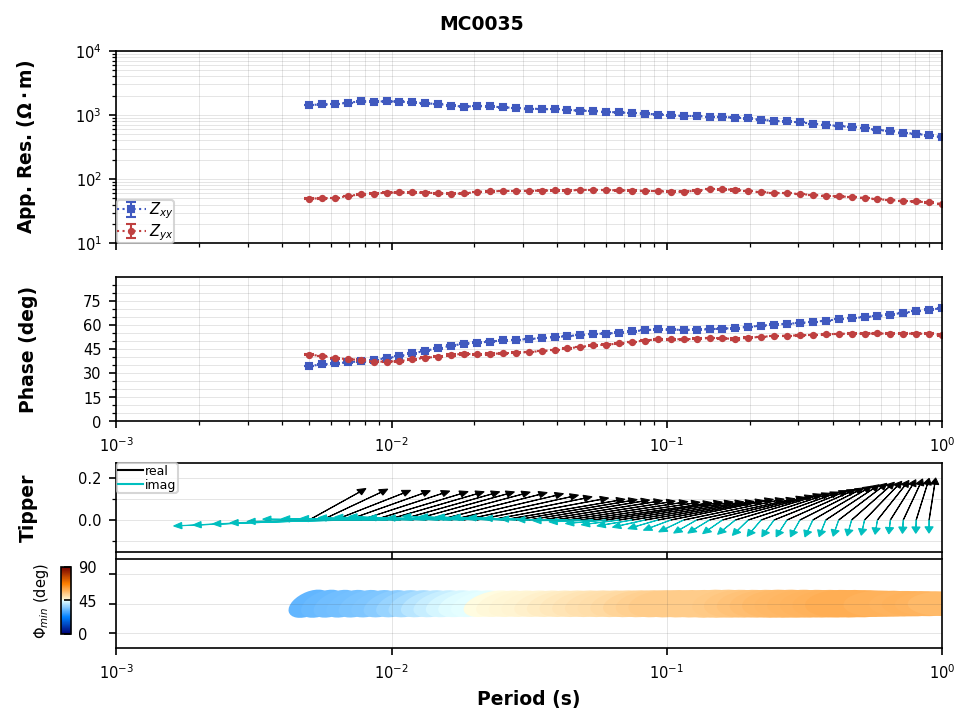

In [64]:
interpo = interpolated_mtd.plot_mt_response("edi.MC0035")

In [65]:
# Mostrar estructura del h5
h5_copy=Path("h5_procesado/"+"collection_crudo.h5")
with h5py.File(h5_copy, "r") as h5file:
    # Función para imprimir la estructura
    def print_structure(name, obj):
        sys.stdout.write(name + '\n')

    # Imprimir la estructura sin truncado
    h5file.visititems(print_structure)

Experiment
Experiment/Reports
Experiment/Standards
Experiment/Standards/summary
Experiment/Surveys
Experiment/Surveys/edi
Experiment/Surveys/edi/Filters
Experiment/Surveys/edi/Filters/coefficient
Experiment/Surveys/edi/Filters/fap
Experiment/Surveys/edi/Filters/fir
Experiment/Surveys/edi/Filters/time_delay
Experiment/Surveys/edi/Filters/zpk
Experiment/Surveys/edi/Reports
Experiment/Surveys/edi/Standards
Experiment/Surveys/edi/Standards/summary
Experiment/Surveys/edi/Stations
Experiment/Surveys/edi/Stations/MC0001
Experiment/Surveys/edi/Stations/MC0001/Fourier_Coefficients
Experiment/Surveys/edi/Stations/MC0001/MC0001a
Experiment/Surveys/edi/Stations/MC0001/MC0001a/ex
Experiment/Surveys/edi/Stations/MC0001/MC0001a/ey
Experiment/Surveys/edi/Stations/MC0001/MC0001a/hx
Experiment/Surveys/edi/Stations/MC0001/MC0001a/hy
Experiment/Surveys/edi/Stations/MC0001/MC0001a/hz
Experiment/Surveys/edi/Stations/MC0001/MC0001a/rrhx
Experiment/Surveys/edi/Stations/MC0001/MC0001a/rrhy
Experiment/Surveys/e

### Eliminar estaciones

Eliminamos las estaciones que presenten alta dipersión a lo largo de todo el rango de frecuencias.

In [66]:
low_period = 1/10**-3  # Periodo mínimo deseado (en segundos)
high_period = 1/10**4 # Periodo máximo deseado (en segundos)
h5_copy=Path("h5_procesado/"+"collection_crudo.h5")
with h5py.File(h5_copy, "r+") as h5file:
    stations_group = h5file['Experiment/Surveys/edi/Stations'] #'Experiment/Surveys/"Survey_ID"/Stations'
    
    # Iterar sobre todas las estaciones en el archivo H5
    for station in stations_group:
        tf_group = stations_group[f'{station}/Transfer_Functions/{station}']
        
        # Acceder a los periodos
        periods = tf_group['period'][:]
        
        # Filtrar los periodos dentro del rango deseado
        period_mask = (periods >= low_period) & (periods <= high_period)
        filtered_periods = periods[period_mask]
        
        # Obtener la transferencia original y el error
        transfer_function = tf_group['transfer_function'][:]
        transfer_function_error = tf_group['transfer_function_error'][:]
        
        # Filtrar la transferencia y el error según el periodo
        filtered_transfer_function = transfer_function[period_mask, :, :]
        filtered_transfer_function_error = transfer_function_error[period_mask, :, :]
        
        # Eliminar los datasets antiguos
        del tf_group['period']
        del tf_group['transfer_function']
        del tf_group['transfer_function_error']
        
        # Crear nuevos datasets con los datos filtrados
        tf_group.create_dataset('period', data=filtered_periods)
        tf_group.create_dataset('transfer_function', data=filtered_transfer_function)
        tf_group.create_dataset('transfer_function_error', data=filtered_transfer_function_error)

        print(f'Estación procesada: {station}')

Estación procesada: MC0001
Estación procesada: MC0002
Estación procesada: MC0006
Estación procesada: MC0007
Estación procesada: MC0008
Estación procesada: MC0009
Estación procesada: MC0010
Estación procesada: MC0011
Estación procesada: MC0012
Estación procesada: MC0013
Estación procesada: MC0014
Estación procesada: MC0015
Estación procesada: MC0016
Estación procesada: MC0018
Estación procesada: MC0019
Estación procesada: MC0020
Estación procesada: MC0021
Estación procesada: MC0022
Estación procesada: MC0024
Estación procesada: MC0025
Estación procesada: MC0027
Estación procesada: MC0028
Estación procesada: MC0029
Estación procesada: MC0030
Estación procesada: MC0031
Estación procesada: MC0032
Estación procesada: MC0033
Estación procesada: MC0034
Estación procesada: MC0035
Estación procesada: MC0036
Estación procesada: MC0037
Estación procesada: MC0038
Estación procesada: MC0039
Estación procesada: MC0040
Estación procesada: MC0041
Estación procesada: MC0042
Estación procesada: MC0043
E

In [67]:
# Lista de estaciones que deseas eliminar
estaciones_a_eliminar = ["MC0051","MC0048", "MC0046", "MC0045", "MC0043", "MC0033", "MC0027", "MC0018", "MC0015", "MC0002"]  #Cambia los nombres de las estaciones según sea necesario
h5_copy=Path("h5_procesado/"+"collection_crudo.h5")

# Abrir el archivo HDF5 en modo de lectura/escritura
with h5py.File(h5_copy, "r+") as h5file:
    stations_group = h5file['Experiment/Surveys/edi/Stations']
    
    # Iterar sobre las estaciones y eliminar las especificadas
    for estacion in estaciones_a_eliminar:
        if estacion in stations_group:
            del stations_group[estacion]
            print(f'Estación {estacion} eliminada.')
        else:
            print(f'Estación {estacion} no encontrada en el archivo.')

Estación MC0051 eliminada.
Estación MC0048 eliminada.
Estación MC0046 eliminada.
Estación MC0045 eliminada.
Estación MC0043 eliminada.
Estación MC0033 eliminada.
Estación MC0027 eliminada.
Estación MC0018 eliminada.
Estación MC0015 eliminada.
Estación MC0002 eliminada.


In [68]:
edi_procesados = Path("Edi_procesado")
edi_procesados.mkdir(exist_ok=True)

for station_tf in interpolated_mtd.mt_list:
    station_id = station_tf.station

    if station_id in estaciones_a_eliminar:
        print(f"Se omite la estación eliminada: {station_id}")
        continue

    t = interpolated_mtd.get_station(station_id, survey_id="edi")
    t.write(save_dir=edi_procesados)
    print(f"Archivo EDI exportado para la estación: {station_id}")

Archivo EDI exportado para la estación: MC0001
Se omite la estación eliminada: MC0002
Archivo EDI exportado para la estación: MC0006
Archivo EDI exportado para la estación: MC0007
Archivo EDI exportado para la estación: MC0008
Archivo EDI exportado para la estación: MC0009
Archivo EDI exportado para la estación: MC0010
Archivo EDI exportado para la estación: MC0011
Archivo EDI exportado para la estación: MC0012
Archivo EDI exportado para la estación: MC0013
Archivo EDI exportado para la estación: MC0014
Se omite la estación eliminada: MC0015
Archivo EDI exportado para la estación: MC0016
Se omite la estación eliminada: MC0018
Archivo EDI exportado para la estación: MC0019
Archivo EDI exportado para la estación: MC0020
Archivo EDI exportado para la estación: MC0021
Archivo EDI exportado para la estación: MC0022
Archivo EDI exportado para la estación: MC0024
Archivo EDI exportado para la estación: MC0025
Se omite la estación eliminada: MC0027
Archivo EDI exportado para la estación: MC002

<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 6 · Exportar sondeos interpolados como EDI</span></div>

Convertir a MTData para exportar los edi procesados
# Crear los .EDI

Visualización y verificación de los datos procesados

In [69]:
# Obtener las frecuencias de cada sondeo

edi_path = Path("Edi_procesado")

frecuencias = []
for station in mc.make_file_list(edi_path, file_types=["edi"]):
    mt_object = MT(station) # Crea un objeto MT de cada edi
    mt_object.read() # Lee el objeto
    frecuencias.extend(1 / mt_object.Z.period)  # Convertir periodos a frecuencias

# Convertir a un array de numpy para mayor eficiencia
frecuencias = np.array(frecuencias)
print(frecuencias.shape)

(2200,)


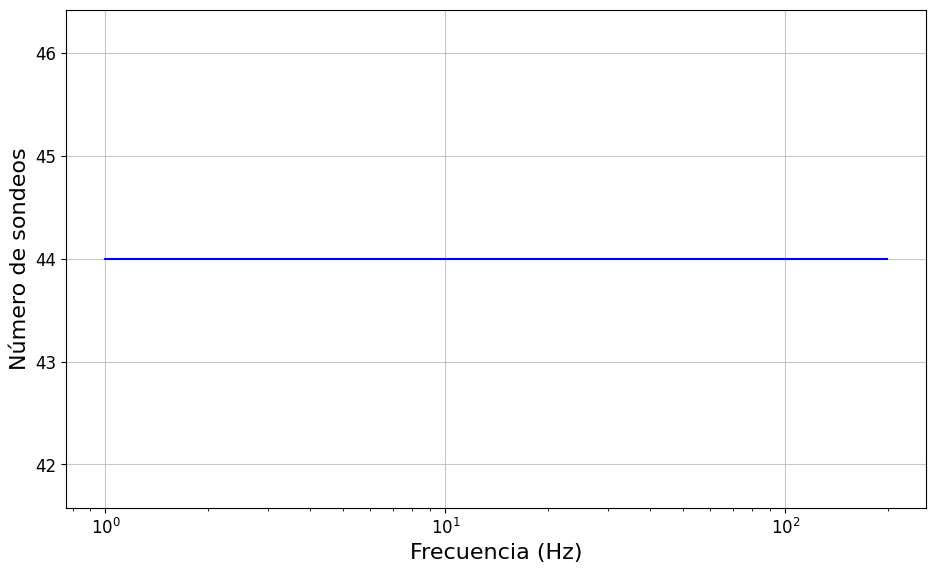

In [70]:
import os
# Definir el nombre de la carpeta y el archivo
folder_path = 'figuras'  # Carpeta donde quieres guardar la imagen
filename = "Estaciones vs Frecuencias.png"  # Nombre del archivo

# Calcular el número de ocurrencia de las frecuencias de los sondeos

unique_freqs, counts = np.unique(frecuencias, return_counts=True)

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(unique_freqs, counts, linestyle="-", color="blue")
plt.xscale("log")
plt.xlabel("Frecuencia (Hz)", fontsize=16)
plt.ylabel("Número de sondeos", fontsize=16)
plt.grid(axis="both", linestyle="-", alpha=0.7)

# Cambiar tamaño de los números en los ejes
plt.tick_params(axis="x", labelsize=12)
plt.tick_params(axis="y", labelsize=12)
fig_path = os.path.join(folder_path, filename)
plt.savefig(fig_path, dpi=300, bbox_inches='tight', format="png")

plt.show()

In [71]:
# Obtener las frecuencias de cada sondeo

frecuencia = []
for station in mc.make_file_list(edi_path, file_types=["edi"]):
    mt_object = MT(station) # Crea un objeto MT de cada edi
    mt_object.read() # Lee el objeto
    frecuencia.append(1 / mt_object.Z.period)  # Convertir periodos a frecuencias
len(frecuencia)

44

In [72]:
estaciones =[]
for station_tf in mtd.mt_list:  
    station_id = station_tf.station 
    estaciones.append(station_id)

len(estaciones)

54

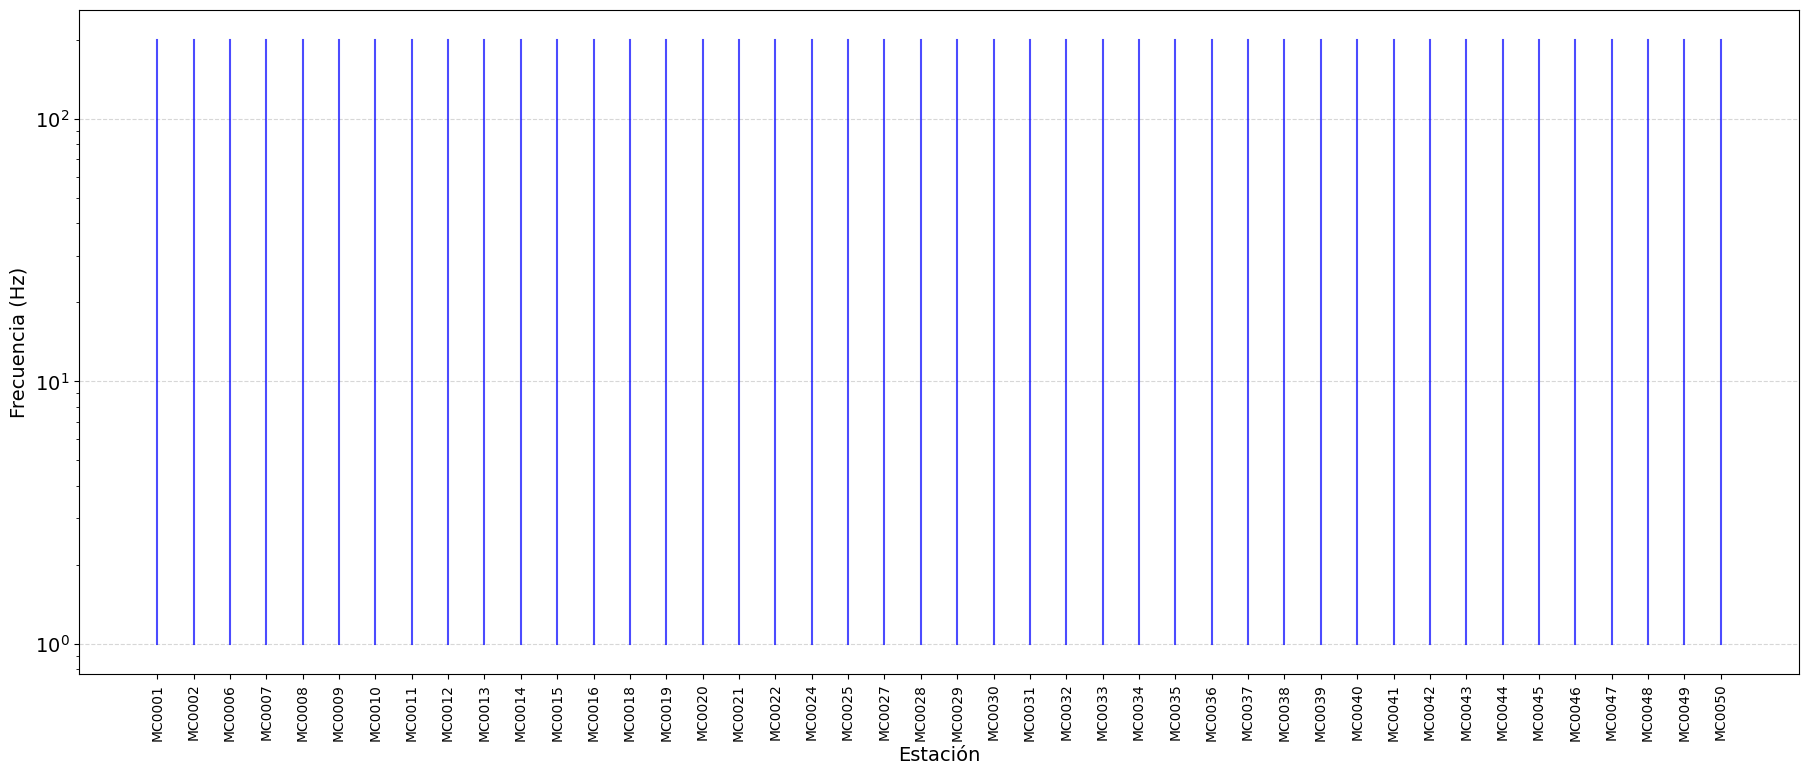

In [73]:
import os
# Definir el nombre de la carpeta y el archivo
folder_path = 'figuras'  # Carpeta donde quieres guardar la imagen
filename = "Estaciones procesadas.png"  # Nombre del archivo

plt.figure(figsize=(20, 8))

for idx, freqs in enumerate(frecuencia):  # Iterar sobre las frecuencias de cada estación
    station_id = estaciones[idx]       # Obtener el ID de la estación
    plt.plot([station_id] * len(freqs), freqs, '-', color="blue", alpha=0.7)  # Graficar cada frecuencia

plt.yscale("log")
plt.xlabel("Estación", fontsize=14)
plt.ylabel("Frecuencia (Hz)", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=14)
fig_path = os.path.join(folder_path, filename)
plt.savefig(fig_path, dpi=300, bbox_inches='tight', format="png")

plt.show()

Organizar los sondeos de mayor a menor cantidad de frecuencias

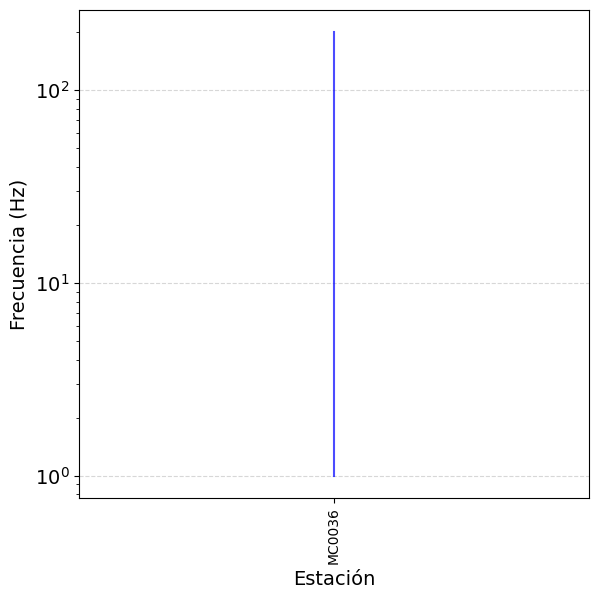

In [74]:

station_target = "MC0036"

# Buscar índice de la estación
if station_target not in estaciones:
    raise ValueError(f"{station_target} no está en la lista de estaciones.")

i = estaciones.index(station_target)
freqs = np.asarray(frecuencia[i])

# (Opcional) filtrar valores inválidos
freqs = freqs[np.isfinite(freqs) & (freqs > 0)]

plt.figure(figsize=(6, 6))
plt.plot([station_target] * len(freqs), freqs, '-', color="blue", alpha=0.7)

plt.yscale("log")
plt.xlabel("Estación", fontsize=14)
plt.ylabel("Frecuencia (Hz)", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.savefig("sondeo_MC0056.png", dpi=300, bbox_inches="tight", format="png")
plt.show()

In [75]:
freq_min = freqs.min()
print(f"[MC0056] Frecuencia mínima = {freq_min:.3e} Hz")
print(f"[MC0056] Frecuencia mínima = 10^{np.log10(freq_min):.2f} Hz")

[MC0056] Frecuencia mínima = 1.000e+00 Hz
[MC0056] Frecuencia mínima = 10^0.00 Hz


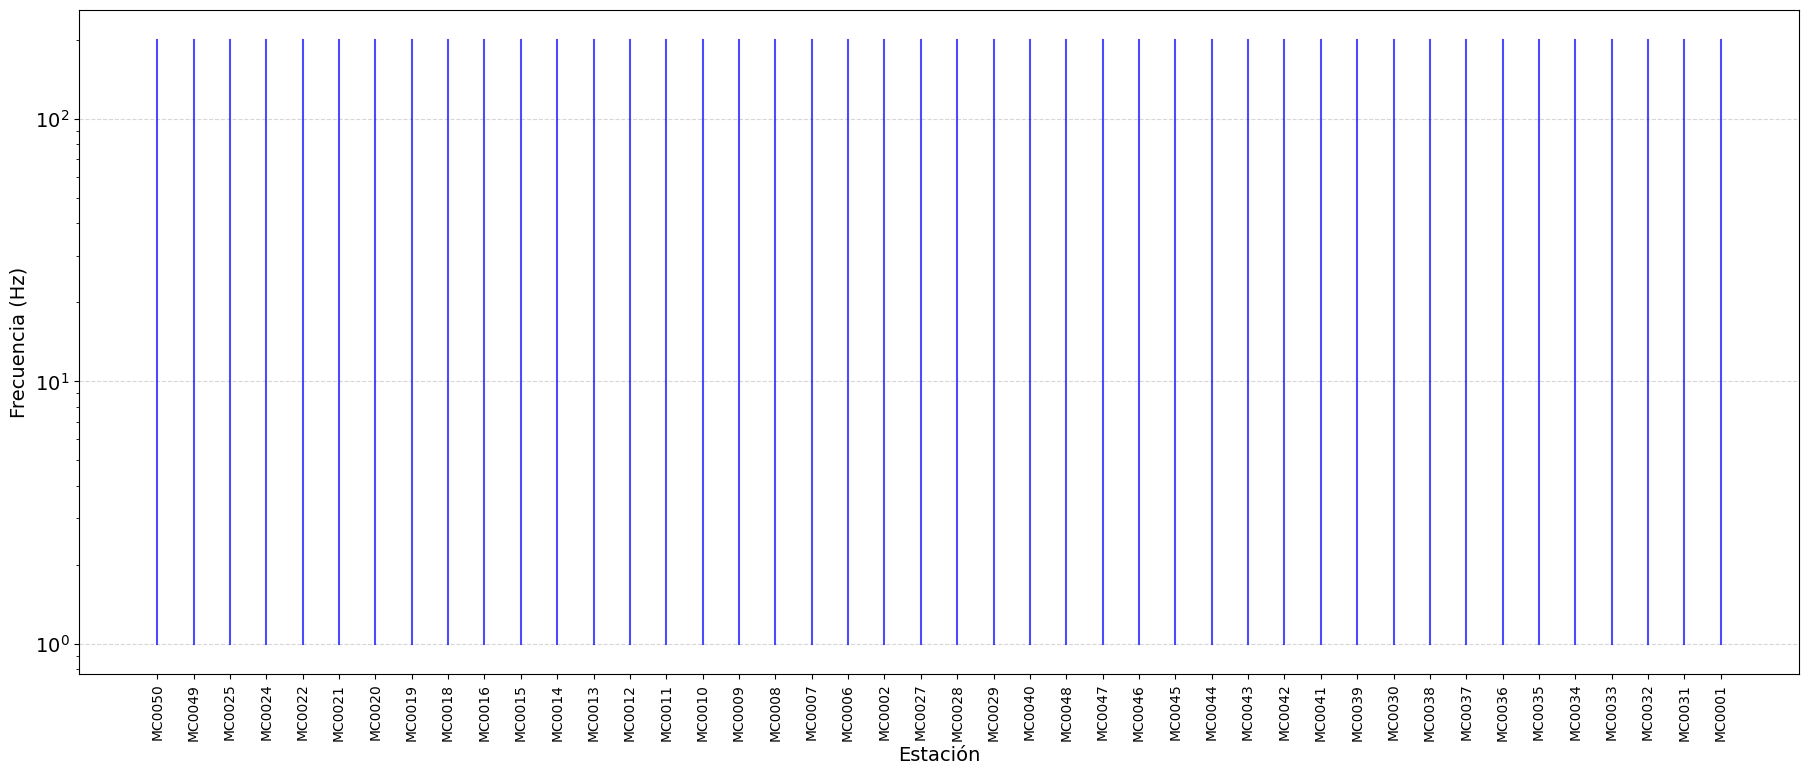

In [76]:
# Contar la cantidad de frecuencias por sondeo
num_frecuencias_por_sondeo = [len(freqs) for freqs in frecuencia]

# Ordenar los sondeos de mayor a menor número de frecuencias
indices_ordenados = np.argsort(num_frecuencias_por_sondeo)[::-1]  # Orden descendente

# Reordenar las listas de estaciones y frecuencias según este orden
estaciones_ordenadas = [estaciones[i] for i in indices_ordenados]
frecuencia_ordenada = [frecuencia[i] for i in indices_ordenados]

# Graficar con las estaciones en el nuevo orden
plt.figure(figsize=(20, 8))

for idx, freqs in enumerate(frecuencia_ordenada):
    station_id = estaciones_ordenadas[idx]
    plt.plot([station_id] * len(freqs), freqs, '-', color="blue", alpha=0.7)

plt.yscale("log")
plt.xlabel("Estación", fontsize=14)
plt.ylabel("Frecuencia (Hz)", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=14)
plt.savefig("sondeos.png", dpi=300, bbox_inches='tight', format="png")
plt.show()


In [77]:
try:
    mc.plot_mt_response("MC0036") # cambiar el nombre de la estación
except:
    pass

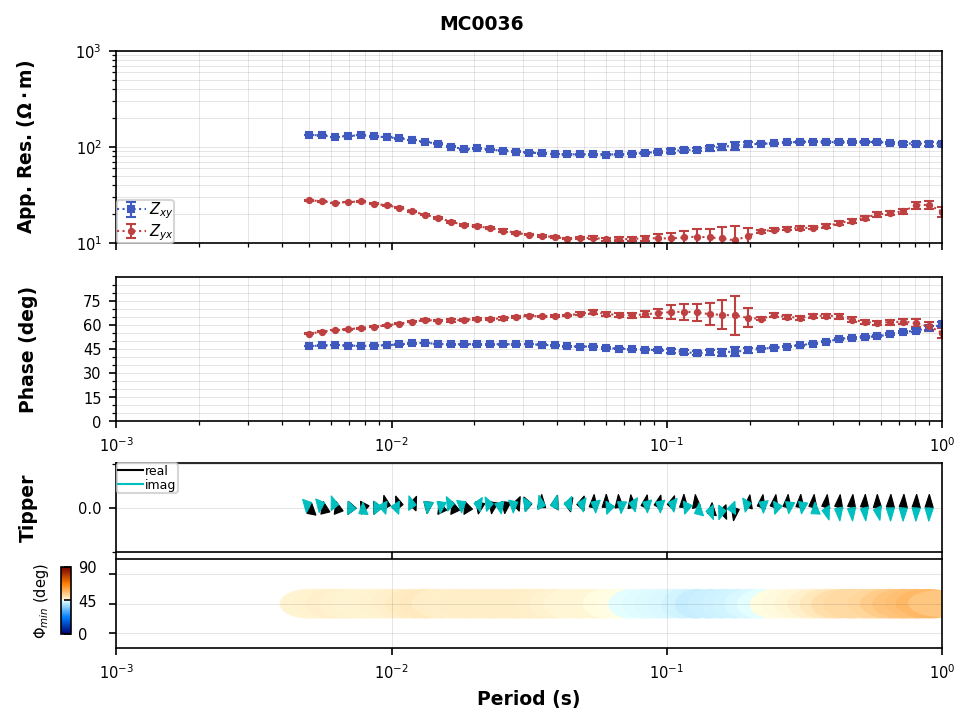

Plotting PlotMTResponse

In [78]:
# Cargar los edis al MTColecction

mt_object = MT('Edi_procesado/MC0036.edi') # Crea un objeto MT de cada edi
mt_object.read() # Lee el objeto
mt_object.plot_mt_response()

In [79]:
mc.close_collection() # Es importante siempre cerrar la colección para evitar daños en el archivo

26:03:17T09:29:36 | WARNING | line:330 |mth5.mth5 | filename | MTH5 file is not open or has not been created yet. Returning default name
26:03:17T09:29:36 | INFO | line:777 |mth5.mth5 | close_mth5 | Flushing and closing h5_procesado\collection_crudo.h5
